# Reference solutions — the exact Runge–Kutta answers

**Purpose.** Before any network exists, build the exact Gauss–Legendre stage states and
endpoints to machine precision, so that a trained model has something to be measured against.

Method: Raissi, Perdikaris & Karniadakis, *Physics-informed neural networks*,
J. Comput. Phys. **378** (2019) 686–707, §3.2. Van der Pol at $\mu = 1$, from $y^n = (2,0)$.

> **No network is trained anywhere in this notebook.** Every error shown is the integration
> scheme's, never a model's.

Produced by `exact_stage_solutions.py` → `results/`, and `paper_figures.py` → `figures/`.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

HERE = Path.cwd()
sys.path.insert(0, str(HERE.parent / "_shared"))
RESULTS, FIGURES = HERE / "results", HERE / "figures"
FIGURES.mkdir(exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "font.size": 9,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "legend.frameon": False,
})
C_EXACT, C_PRIN, C_SPUR = "#33322e", "#2a78d6", "#e34948"
print("cwd:", HERE.name)


cwd: reference_solutions


## 1. The tableaux

Gauss–Legendre nodes $c_i$ are the roots of the shifted Legendre polynomial; the weights $b_j$
and the matrix $a_{ij}$ follow from the order conditions
$\sum_j b_j c_j^{k-1} = 1/k$ and $\sum_j a_{ij} c_j^{k-1} = c_i^k / k$.

That Vandermonde system is badly ill-conditioned — at $q = 8$ the float64 Legendre roots
collide outright — so `runge_kutta.py` seeds the roots from `numpy`, polishes them with
`mpmath.findroot`, and solves at 60 digits before casting to float64.

Checked against the two closed forms: $q=1$ is the implicit midpoint rule, $q=2$ the classical
fourth-order tableau.

In [2]:
tab = pd.read_csv(RESULTS / "tableaux.csv")
print(f"max |computed - closed form| = {tab.abs_err.max():.2e}")
tab

max |computed - closed form| = 1.11e-16


,q,quantity,value,expected,abs_err
0,1,c[0],0.500000,0.500000,0.000000e+00
1,1,b[0],1.000000,1.000000,0.000000e+00
2,1,A[0],0.500000,0.500000,0.000000e+00
3,2,c[0],0.211325,0.211325,2.775558e-17
4,2,c[1],0.788675,0.788675,1.110223e-16
5,2,b[0],0.500000,0.500000,0.000000e+00
6,2,b[1],0.500000,0.500000,0.000000e+00
7,2,A[0],0.250000,0.250000,0.000000e+00
8,2,A[1],-0.038675,-0.038675,1.387779e-17
9,2,A[2],0.538675,0.538675,0.000000e+00


## 2. How accurate is the reference itself?

Everything below is an error *measured against* a Radau solution at `rtol = atol = 1e-12`.
Below the accuracy of that reference, a small number means nothing at all. Two independent
estimates:

- **Radau self-consistency** — the same integrator at `rtol = 1e-14` (scipy clamps at
  $2.2\times10^{-14}$, so that is the tightest available).
- **A completely different method** — a single Gauss–Legendre step at $q = 12$, order 24.

They agree, which is the point of using two.

> One trap. The $q=12$ comparison is only meaningful where *its own* truncation error is
> negligible. At $\Delta t = 2$ it is not, and the $4.6\times10^{-12}$ in that row is $q=12$'s
> error, not the reference's. Collapsing this table to a single global maximum inflates the
> floor 300-fold and silently throws away good data — so the floor is kept **per step size**.

In [3]:
floor = pd.read_csv(RESULTS / "reference_floor.csv")
valid = floor[floor.q12_is_a_valid_comparator]
print(f"reference floor spans {floor.radau_self_consistency.min():.1e} "
      f"to {floor.radau_self_consistency.max():.1e}")
print(f"two independent methods agree to {valid.vs_gauss_legendre_q12.max():.1e} for dt <= 1")
floor.style.format({"radau_self_consistency": "{:.2e}",
                    "vs_gauss_legendre_q12": "{:.2e}"})

reference floor spans 5.3e-15 to 3.9e-14
two independent methods agree to 1.4e-14 for dt <= 1


,dt,radau_self_consistency,vs_gauss_legendre_q12,q12_is_a_valid_comparator
0,0.025000,5.73e-15,4.85e-15,True
1,0.050000,8.50e-15,5.08e-15,True
2,0.100000,5.71e-15,5.56e-15,True
3,0.200000,7.33e-15,7.17e-15,True
4,0.400000,5.34e-15,8.51e-15,True
5,0.500000,1.19e-14,8.71e-15,True
6,0.800000,9.43e-15,1.05e-14,True
7,1.000000,1.25e-14,1.39e-14,True
8,2.000000,3.93e-14,4.58e-12,False


## 3. Order $2q$ — and where it stops being measurable

A $q$-stage Gauss–Legendre method has global order $2q$, so a **single step** has local error
$\mathcal{O}(\Delta t^{2q+1})$.

That slope only appears once $\Delta t$ is small enough. Filled markers clear the reference
floor by a factor of 20; hollow ones sit at it and carry no information.

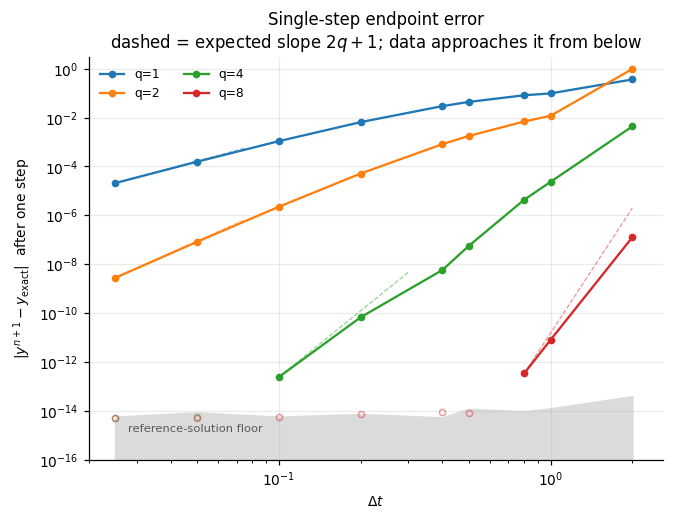

dt,0.025,0.050,0.100,0.200,0.400,0.500,0.800,1.000,2.000
q,,,,,,,,,
1,2.1e-05,1.6e-04,1.1e-03,6.5e-03,2.9e-02,4.4e-02,8.2e-02,9.8e-02,3.6e-01
2,2.8e-09,8.2e-08,2.2e-06,5.1e-05,8.2e-04,1.8e-03,6.9e-03,1.2e-02,9.8e-01
4,4.8e-15,5.7e-15,2.4e-13,6.7e-11,5.8e-09,5.5e-08,4.3e-06,2.3e-05,4.4e-03
8,4.8e-15,5.1e-15,5.6e-15,7.1e-15,8.5e-15,8.0e-15,3.4e-13,7.9e-12,1.3e-07


In [4]:
conv = pd.read_csv(RESULTS / "convergence.csv")
f = floor.sort_values("dt")

fig, ax = plt.subplots(figsize=(6.2, 4.8))
ax.fill_between(f.dt, 1e-16, f.radau_self_consistency, color="0.86", zorder=0)
ax.text(0.028, 1.4e-15, "reference-solution floor", fontsize=7.5, color="0.35", zorder=1)

for q, g in conv.groupby("q"):
    g = g.sort_values("dt")
    good, bad = g[g.above_floor], g[~g.above_floor]
    line, = ax.loglog(good.dt, good.endpoint_err, "o-", ms=4, label=f"q={q}")
    ax.loglog(bad.dt, bad.endpoint_err, "o", ms=4, mfc="none", alpha=0.45,
              color=line.get_color())
    if len(good):                      # slope guide, anchored at the smallest usable point
        d0, e0 = good.dt.iloc[0], good.endpoint_err.iloc[0]
        dd = np.array([d0, min(d0 * 3, conv.dt.max())])
        ax.loglog(dd, e0 * (dd / d0) ** (2 * q + 1), "--", lw=0.8, alpha=0.5,
                  color=line.get_color())

ax.set_xlabel(r"$\Delta t$")
ax.set_ylabel(r"$|y^{n+1} - y_{\rm exact}|$  after one step")
ax.set_title("Single-step endpoint error\ndashed = expected slope $2q+1$; data approaches it from below")
ax.set_xlim(0.02, 2.6)
ax.set_ylim(1e-16, 3)
ax.legend(fontsize=8, ncol=2, loc="upper left")
fig.tight_layout(); fig.savefig(FIGURES / "convergence.png"); plt.show()

conv.pivot(index="q", columns="dt", values="endpoint_err").map(lambda v: f"{v:.1e}")

### The fitted order

Fitted on the two smallest step sizes that clear the floor. The slope approaches $2q+1$ **from
below**, so a fit on coarse steps under-reports. Large $q$ runs out of room: the reference floor
rises to meet it before $\Delta t$ is small enough to reach the asymptotic slope. That is a
limitation of the *measurement*, not of the scheme, and it is exactly the rehearsal for the
network floor we expect later.

In [5]:
rows = []
for q, g in conv.groupby("q"):
    g = g[g.above_floor].sort_values("dt")
    if len(g) < 2:
        rows.append(dict(q=q, expected=2 * q + 1, observed=np.nan,
                         fitted_on="not measurable", asymptotic=False))
        continue
    g = g.head(2)
    p = np.polyfit(np.log(g.dt), np.log(g.endpoint_err), 1)[0]
    rows.append(dict(q=q, expected=2 * q + 1, observed=round(p, 2),
                     fitted_on=str(list(np.round(g.dt, 3))),
                     asymptotic=bool(g.dt.iloc[0] <= 0.05)))
pd.DataFrame(rows)

,q,expected,observed,fitted_on,asymptotic
0,1,3,2.90,"[0.025, 0.05]",True
1,2,5,4.89,"[0.025, 0.05]",True
2,4,9,8.13,"[0.1, 0.2]",False
3,8,17,14.11,"[0.8, 1.0]",False


## 4. The stages do *not* superconverge; only the endpoint does

A picture of stage states sitting on the exact arc flatters the method. Gauss–Legendre has
**stage order $q$** — a single stage state is accurate to $\mathcal{O}(\Delta t^{q+1})$ — while
the *endpoint* superconverges to $\mathcal{O}(\Delta t^{2q+1})$.

This matters here because the network is asked to predict the **stages**. Their accuracy, not
the endpoint's, is what its capacity has to support.

> **A measurement trap, and it bit me.** The stage states must be compared against a *computed
> endpoint* at $t^n + c_i \Delta t$, not against `sol.sol(c_i*dt)`. The latter is Radau's dense
> interpolant at an interior point, good only to $\sim10^{-13}$ — three orders worse than its
> endpoint. Using it makes the stage error flatten at small $\Delta t$ and fakes a floor that
> belongs to the interpolant rather than to the scheme.

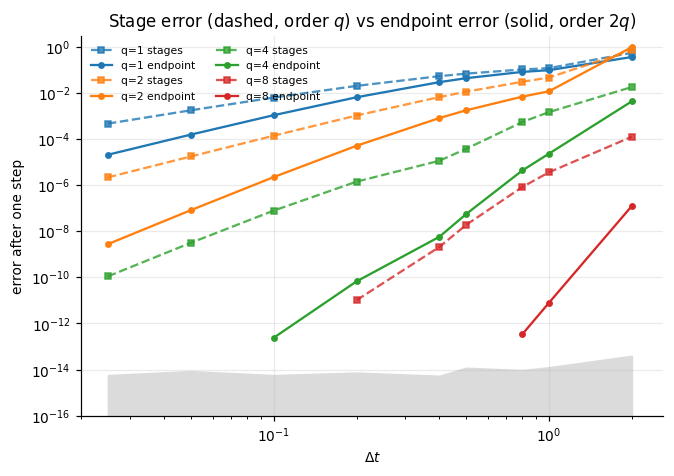

,q,stage_order_expected,stage_order_observed,endpoint_order_expected,stages_worse_by_at_dt1
0,1,2,1.92,3,1.2
1,2,3,3.01,5,4.0
2,4,5,4.83,9,63.5
3,8,9,7.68,17,457317.4


In [6]:
fig, ax = plt.subplots(figsize=(6.2, 4.4))
for q, g in conv.groupby("q"):
    g = g.sort_values("dt")
    sg, eg = g[g.stage_above_floor], g[g.above_floor]
    l, = ax.loglog(sg.dt, sg.stage_err, "s--", ms=3.5, alpha=0.8, label=f"q={q} stages")
    ax.loglog(eg.dt, eg.endpoint_err, "o-", ms=3.5, color=l.get_color(),
              label=f"q={q} endpoint")
ax.fill_between(f.dt, 1e-16, f.radau_self_consistency, color="0.86", zorder=0)
ax.set_xlabel(r"$\Delta t$"); ax.set_ylabel("error after one step")
ax.set_title("Stage error (dashed, order $q$) vs endpoint error (solid, order $2q$)")
ax.set_xlim(0.02, 2.6); ax.set_ylim(1e-16, 3); ax.legend(fontsize=7, ncol=2, loc="upper left")
fig.tight_layout(); fig.savefig(FIGURES / "stage_vs_endpoint.png"); plt.show()

rows = []
for q, g in conv.groupby("q"):
    s = g[g.stage_above_floor].sort_values("dt").head(2)
    p = np.polyfit(np.log(s.dt), np.log(s.stage_err), 1)[0] if len(s) == 2 else np.nan
    at1 = g[g.dt == 1.0].iloc[0]
    rows.append(dict(q=q, stage_order_expected=q + 1, stage_order_observed=round(p, 2),
                     endpoint_order_expected=2 * q + 1,
                     stages_worse_by_at_dt1=round(at1.stage_err / at1.endpoint_err, 1)))
pd.DataFrame(rows)

## 5. The reconstruction identity — this **is** the loss

Rearranging each of the $q+1$ Runge–Kutta relations gives an expression for the one state that
is already known, $y^n$:

$$y^n_i := Y_i - \Delta t \sum_j a_{ij}\, f(Y_j), \qquad
  y^n_{q+1} := y^{n+1} - \Delta t \sum_j b_j\, f(Y_j)$$

At the converged stage solution every one of them must return $y^n$. **The RK-PINN loss is
exactly the squared failure of this identity.** Evaluated here at the exact answer, so it
should be zero to machine precision — and it is.

In [7]:
rec = pd.read_csv(RESULTS / "reconstruction.csv")
print(f"max deviation of any reconstruction from y^n = {rec.dev.max():.2e}")
print(f"max stage-solve residual                     = {conv.stage_residual.max():.2e}")
print()
print("the q+1 = 5 reconstructions at q=4, dt=1.0 (each should be exactly (2, 0)):")
rec[(rec.q == 4) & (rec.dt == 1.0)][["relation", "y1", "y2", "dev"]]

max deviation of any reconstruction from y^n = 3.33e-16
max stage-solve residual                     = 3.33e-16

the q+1 = 5 reconstructions at q=4, dt=1.0 (each should be exactly (2, 0)):


,relation,y1,y2,dev
80,1,2.0,-1.387779e-17,1.387779e-17
81,2,2.0,0.000000e+00,0.000000e+00
82,3,2.0,-1.110223e-16,1.110223e-16
83,4,2.0,0.000000e+00,0.000000e+00
84,5,2.0,0.000000e+00,0.000000e+00


## 6. The two figures

`paper_figures.py` emits hand-rolled SVG. Notion's attachment API takes the file inline as a
UTF-8 string, so matplotlib's per-glyph outlines (~90 KiB) are far too large to transcribe;
these are ~10 KiB.

- `two_models.svg` — the continuous-time model (§3.1) beside the discrete-time model (§3.2),
  with the $q+1$ dashed arrows collapsing back onto $y^n$: the loss, drawn.
- `order_vs_stages.svg` — order $2q$, and a single $\Delta t = 2$ step where explicit RK4 is
  unstable while Gauss–Legendre is not.

two_models.svg: 10.5 KiB


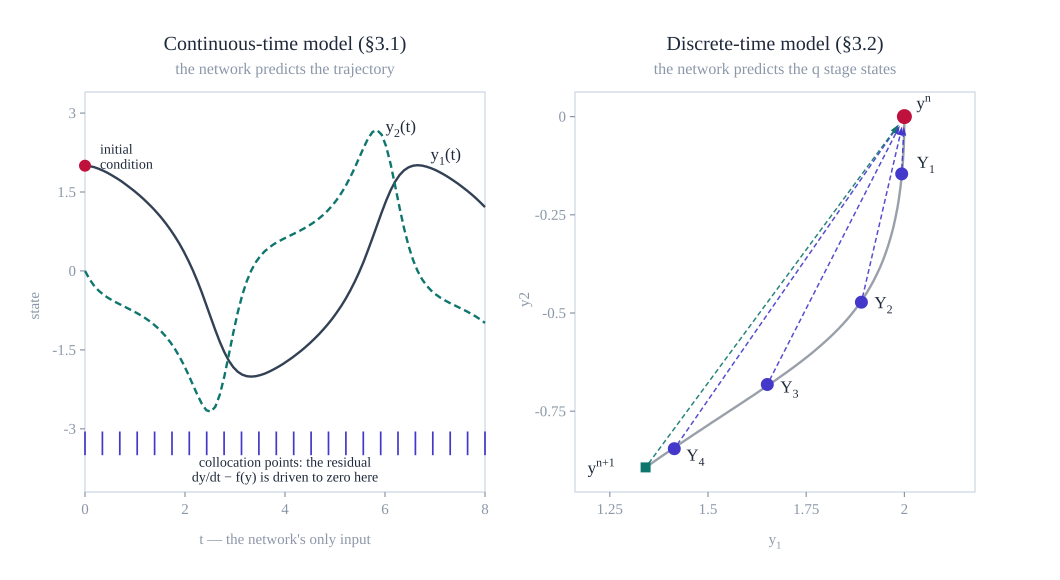

order_vs_stages.svg: 9.4 KiB


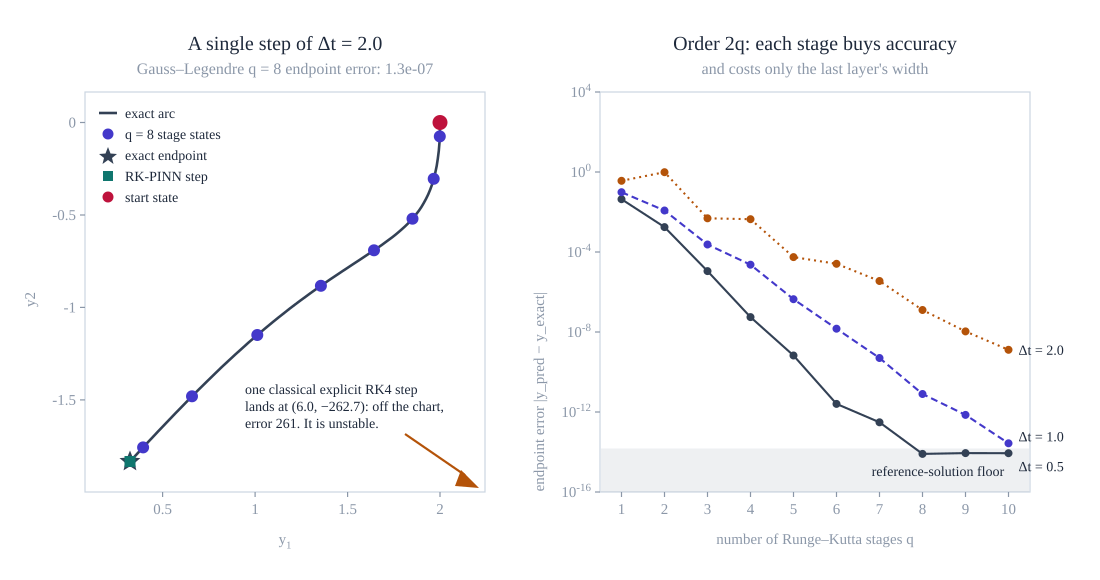

In [8]:
from IPython.display import SVG, display
for nm in ("two_models", "order_vs_stages"):
    p = FIGURES / f"{nm}.svg"
    print(f"{p.name}: {p.stat().st_size/1024:.1f} KiB")
    display(SVG(filename=str(p)))